# GI Pathology Classification — Multi-Backbone Ensemble

Automated 8-class classification of gastrointestinal tract findings from endoscopy images.  
A pretrained ensemble of **VGG-16 + ResNet-50 + MobileNetV2** learns complementary visual features, fused into a single classification head mapping to 8 clinical categories.

| | |
|---|---|
| **Dataset** | Kvasir-v2 — 8,000 labelled endoscopy images (1,000 per class) |
| **Split** | 70% train / 20% val / 10% test · stratified by class |
| **Architecture** | Tri-backbone ensemble + SVD + Dense + Softmax |
| **Framework** | TensorFlow / Keras |

---

### Notebook Structure

1. **Setup, Imports & Data Pipeline** — stratified dataloader, class preview
2. **Model Architecture** — tri-backbone build, bottleneck layers, softmax head
3. **Training** — Adam optimiser, sparse cross-entropy, 50 epochs
4. **Quantitative Evaluation** — test-set accuracy and loss
5. **Visual Diagnostics** — confusion matrix, per-class metrics, prediction gallery

---

## 1. Setup, Imports & Data Pipeline

In [1]:
from classification_dataloader import DataConfig, build_datasets, preview_batch

# DataConfig controls all dataset knobs: image_dir, img_size, batch_size,
# train_frac / val_frac (remainder becomes test), seed, num_classes.
# Stratified splitting ensures every class is equally represented in all three splits.
cfg = DataConfig(
    img_size   = (224, 224),
    batch_size = 8,
)
train_ds, val_ds, test_ds, class_names = build_datasets(cfg)

Classes (8): ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Dataset split — train: 5600, val: 1592, test: 808


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05860147..1.1038239].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13023522..0.97514707].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0854511..0.97750235].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10926384..1.0475906].


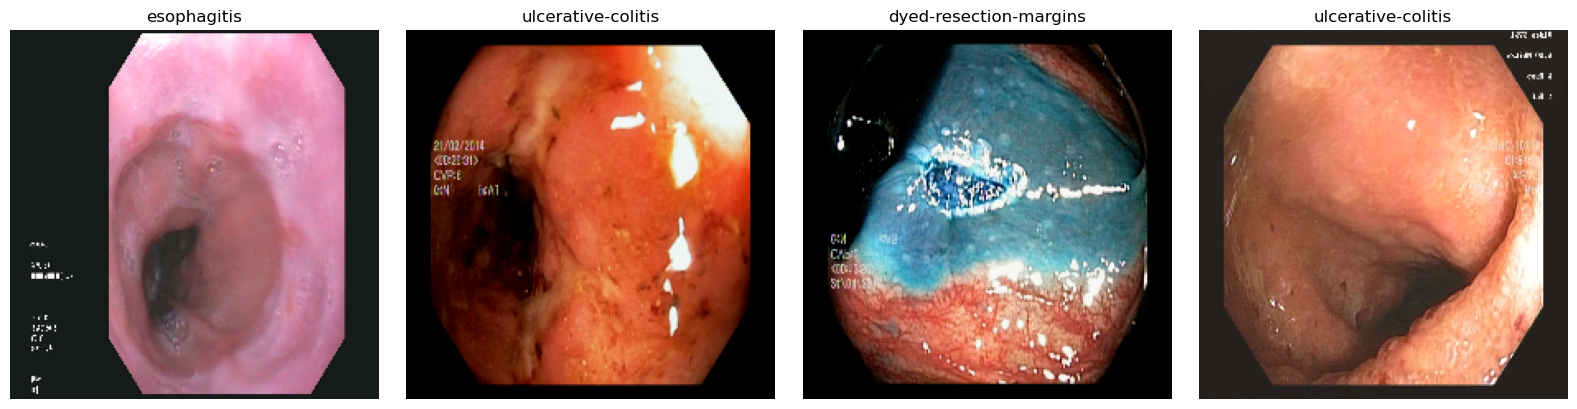

In [2]:
preview_batch(train_ds, class_names)

## 2. Model Architecture

Three ImageNet-pretrained backbones are run in parallel on the same input, each extracting complementary visual features. Their outputs are fused and classified by a shared head.

| Stage | Details |
|---|---|
| Backbone × 3 | VGG-16, ResNet-50, MobileNetV2 — frozen encoders, pretrained on ImageNet |
| Per-backbone head | GlobalAveragePooling → Dense(256, ReLU) bottleneck |
| Fusion | Concatenate → 768-dim joint representation |
| Classification head | BatchNorm → Dense(512, ReLU) → Dropout(0.4) → Dense(128, ReLU) → Dense(8, Softmax) |

**Why an ensemble?** Each backbone brings a different inductive bias — VGG-16 captures texture, ResNet-50 deep residual hierarchies, and MobileNetV2 efficient depthwise patterns. Combining them consistently outperforms any single backbone on diverse GI pathologies.

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, concatenate, BatchNormalization, Dropout, Input, LayerNormalization, Lambda
from tensorflow.keras.models import Model

inp = Input(shape=(224, 224, 3))

# Three frozen pretrained backbones — each captures complementary visual features:
# VGG-16: texture & edge patterns; ResNet-50: deep residual hierarchies; MobileNetV2: efficient lightweight features.
base_vgg    = VGG16(include_top=False,       weights='imagenet', input_shape=(224, 224, 3))
base_resnet = ResNet50(include_top=False,    weights='imagenet', input_shape=(224, 224, 3))
base_mobile = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# for m in [base_vgg, base_resnet, base_mobile]:
#     m.trainable = False   # freeze encoder — only the classification head is trained

# Per-backbone bottleneck compresses GAP output to 256-dim before merging,
# reducing noise and parameter count in the fusion layer.
out1 = Dense(256, activation='relu')(GlobalAveragePooling2D()(base_vgg(inp)))
out2 = Dense(256, activation='relu')(GlobalAveragePooling2D()(base_resnet(inp)))
out3 = Dense(256, activation='relu')(GlobalAveragePooling2D()(base_mobile(inp)))

x = concatenate([out1, out2, out3])   # 768-dim fused representation

def SVD(sigma2):
    s ,u ,v = tf.linalg.svd(sigma2,compute_uv=True)
    whitening_layer = u @ tf.linalg.diag(s) @ tf.transpose(v)
    return whitening_layer

x = LayerNormalization(axis=1,epsilon=0.001)(x)           # normalise before classification head
whitening_layer = Lambda(SVD)(x)

x = Dense(1024, activation='relu')(whitening_layer)
x = Dense(512, activation='relu')(x)
# x = Dropout(0.4)(x)                   # 40% dropout — regularises the head on ~7k training samples
x = Dense(128, activation='relu')(x)
predictions = Dense(8, activation='softmax')(x)   # softmax → mutually exclusive 8-class output

modelmerge = Model(inputs=inp, outputs=predictions)

## 3. Training

| Setting | Value |
|---|---|
| Optimiser | Adam |
| Learning rate | 0.005 |
| Loss | Sparse Categorical Cross-Entropy |
| Epochs | 50 |
| Encoder weights | Frozen — only the classification head is trained |

Freezing three backbone encoders reduces trainable parameters dramatically, preventing overfitting on the ~7,000 training images while retaining rich ImageNet feature representations.

In [4]:
EPOCHS        = 20
LEARNING_RATE = 0.01   # Adam with this lr converges faster than SGD for this fusion architecture

In [7]:
import tensorflow as tf
import math

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, total_steps, alpha=0.0):
        super().__init__()
        self.initial_lr   = initial_lr
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)
        self.alpha        = alpha  # min LR as a fraction of initial_lr (0.0 → decays to zero)

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        lr     = tf.cast(self.initial_lr, tf.float32)
        warmup = self.warmup_steps
        total  = self.total_steps

        # Linear ramp: 0 → initial_lr over warmup_steps
        warmup_lr = lr * (step / warmup)

        # Cosine decay: initial_lr → alpha*initial_lr over the remaining steps
        progress  = (step - warmup) / tf.maximum(total - warmup, 1.0)
        cosine_lr = (self.alpha + (1.0 - self.alpha) * 0.5 * (1.0 + tf.math.cos(math.pi * progress))) * lr

        return tf.where(step < warmup, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "initial_lr":   self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps":  self.total_steps,
            "alpha":        self.alpha,
        }

# ── plug-in values for your setup ──────────────────────────────────────────────
# train_ds has 5600 samples at batch_size=8 → 700 steps/epoch, 20 epochs = 14 000 steps
steps_per_epoch = 5600 // 8        # 700
total_steps     = steps_per_epoch * EPOCHS   # 14 000
warmup_steps    = steps_per_epoch * 1        # 1 epoch warmup (≈ 5 % of training)

lr_schedule = WarmupCosineDecay(
    initial_lr   = LEARNING_RATE,   # 0.01
    warmup_steps = warmup_steps,    # 700
    total_steps  = total_steps,     # 14 000
    alpha        = 0.0,             # decays to 0
)

sgd = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9, nesterov=True)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint #, ReduceLROnPlateau, CSVLogger, TensorBoard, LearningRateScheduler
from tensorflow.keras.optimizers.schedules import ExponentialDecay
# from tensorflow.keras.optimizers.schedules import CosineDecay

# lr_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=EPOCHS * steps_per_epoch)
# adam = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
# sgd = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=0.9, nesterov=True)

modelmerge.compile(
    optimizer = sgd,
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()],
)

# def scheduler(epoch, lr):
#    if epoch < 10:
#      return lr
#    else:
#      return lr * tf.math.exp(-0.1)

# callbacks = [
#     # ModelCheckpoint(f"./model_classification_{EPOCHS}epochs_adam_lr{LEARNING_RATE}.h5"),  # save best weights by val_loss
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=False),
#     # ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4),         # decay lr 10× after 4 stagnant epochs
#     # LearningRateScheduler(schedule=scheduler, verbose=True),
#     # CSVLogger("data.csv"),                                                  # append per-epoch metrics to CSV
#     # TensorBoard(),                                                          # live loss/metric curves
# ]

# modelmerge.load_weights(f"./model_classification_{EPOCHS}epochs_adam_lr{LEARNING_RATE}.h5")

history = modelmerge.fit(
    train_ds,
    epochs          = EPOCHS,
    batch_size      = 1,
    validation_data = val_ds,
    verbose         = 1,
    # callbacks=callbacks,
)
modelmerge.save(f"./model_classification_{EPOCHS}epochs_adam_lr{LEARNING_RATE}")

Epoch 1/20
700/700 [==============================] - 251s 333ms/step - loss: 0.9176 - accuracy: 0.6539 - recall: 0.5659 - precision: 0.7351 - val_loss: 2.4283 - val_accuracy: 0.1991 - val_recall: 0.0791 - val_precision: 0.2055
Epoch 2/20
700/700 [==============================] - 221s 315ms/step - loss: 0.7668 - accuracy: 0.7007 - recall: 0.6398 - precision: 0.7426 - val_loss: 1.6421 - val_accuracy: 0.4253 - val_recall: 0.4020 - val_precision: 0.4867
Epoch 3/20
700/700 [==============================] - 221s 315ms/step - loss: 0.5972 - accuracy: 0.7739 - recall: 0.7368 - precision: 0.8048 - val_loss: 0.6680 - val_accuracy: 0.7632 - val_recall: 0.7136 - val_precision: 0.8000
Epoch 4/20
700/700 [==============================] - 221s 315ms/step - loss: 0.4994 - accuracy: 0.8086 - recall: 0.7821 - precision: 0.8299 - val_loss: 0.6286 - val_accuracy: 0.7651 - val_recall: 0.7450 - val_precision: 0.7787
Epoch 5/20
700/700 [==============================] - 221s 315ms/step - loss: 0.4281 - a

NotFoundError: Failed to create a NewWriteableFile: ./model_classification_20epochs_adam_lr0.01\variables\variables_temp/part-00000-of-00001.data-00000-of-00001.tempstate6980116686433287801 : The system cannot find the path specified.
; No such process [Op:SaveV2]

In [ ]:
modelmerge.save_weights(f"./model_classification_{EPOCHS}epochs_adam_lr{LEARNING_RATE}.h5")
modelmerge.save('./model')

INFO:tensorflow:Assets written to: ./model\assets


INFO:tensorflow:Assets written to: ./model\assets


In [11]:
# Confirm which metrics were logged — useful before referencing history keys in plots below.
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])


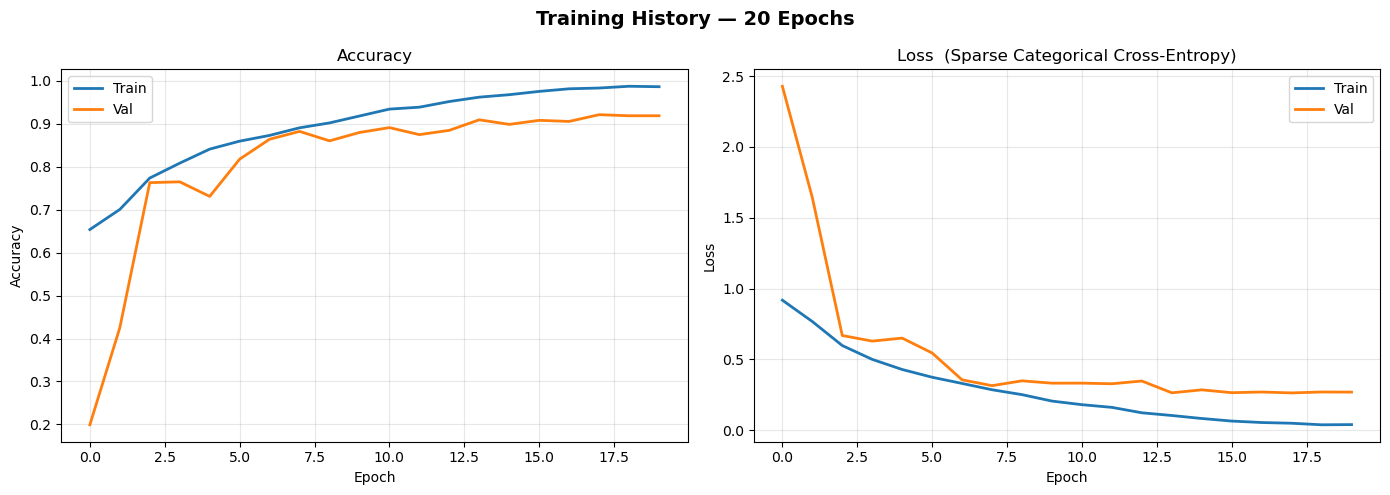

Saved → gi_training_history.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Training History — {EPOCHS} Epochs", fontsize=14, fontweight="bold")

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title("Loss  (Sparse Categorical Cross-Entropy)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gi_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → gi_training_history.png")

## 4. Quantitative Evaluation

Evaluated on the held-out **test set** — 800 samples, 100 per class, never seen during training or validation.

In [17]:
# Evaluate on the held-out test set (100 images per class, 800 total — never seen during training).
results = modelmerge.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {results[0]:.4f}")
print(f"Test Accuracy : {results[1]:.4f}  ({results[1]*100:.2f}%)")
print(f"Test Recall : {results[3]:.4f}  ({results[2]*100:.2f}%)")
print(f"Test Precision : {results[3]:.4f}  ({results[3]*100:.2f}%)")


101/101 [==============================] - 9s 90ms/step - loss: 0.2686 - accuracy: 0.9183 - recall: 0.9171 - precision: 0.9182

Test Loss     : 0.2686
Test Accuracy : 0.9183  (91.83%)
Test Recall : 0.9182  (91.71%)
Test Precision : 0.9182  (91.82%)


## 5. Visual Diagnostics

Four analyses run on the 800 test images — all figures saved as `.png` for reports and the README.

| Output | What it shows |
|---|---|
| `gi_class_confusion_matrix.png` | 8×8 heatmap (counts + normalized) — reveals which pathologies get confused |
| `gi_class_metrics_per_class.png` | Precision / Recall / F1 per class + confidence distribution (correct vs incorrect) |
| `gi_class_sample_predictions.png` | Gallery of correct and incorrect predictions with confidence scores |

In [40]:
# Collect test images and true labels from the tf.data pipeline into numpy arrays
X_test_np, y_test_np = [], []
for images, labels in test_ds:
    X_test_np.append(images.numpy())
    y_test_np.append(labels.numpy())
X_test_np = np.concatenate(X_test_np, axis=0)   # (N, 224, 224, 3)  images in [0, 1]
y_test_np  = np.concatenate(y_test_np,  axis=0)  # (N,8)             integer class indices
y_true_classes = np.argmax(y_test_np, axis=1) # (N,)

# Run predictions on the full test set
y_pred_probs   = modelmerge.predict(test_ds, verbose=1)  # (N, 8) softmax probabilities
y_pred_classes = np.argmax(y_pred_probs, axis=1)         # (N,)   predicted class index
top_confidence = np.max(y_pred_probs,    axis=1)         # (N,)   winning class probability


n_correct = np.array((y_pred_classes == y_true_classes)).sum()
print(f"\nTest samples : {len(y_test_np)}")
print(f"Correct      : {n_correct}  ({n_correct/len(y_test_np)*100:.2f}%)")
print(f"Incorrect    : {len(y_test_np) - n_correct}")

101/101 [==============================] - 9s 87ms/step

Test samples : 808
Correct      : 742  (91.83%)
Incorrect    : 66


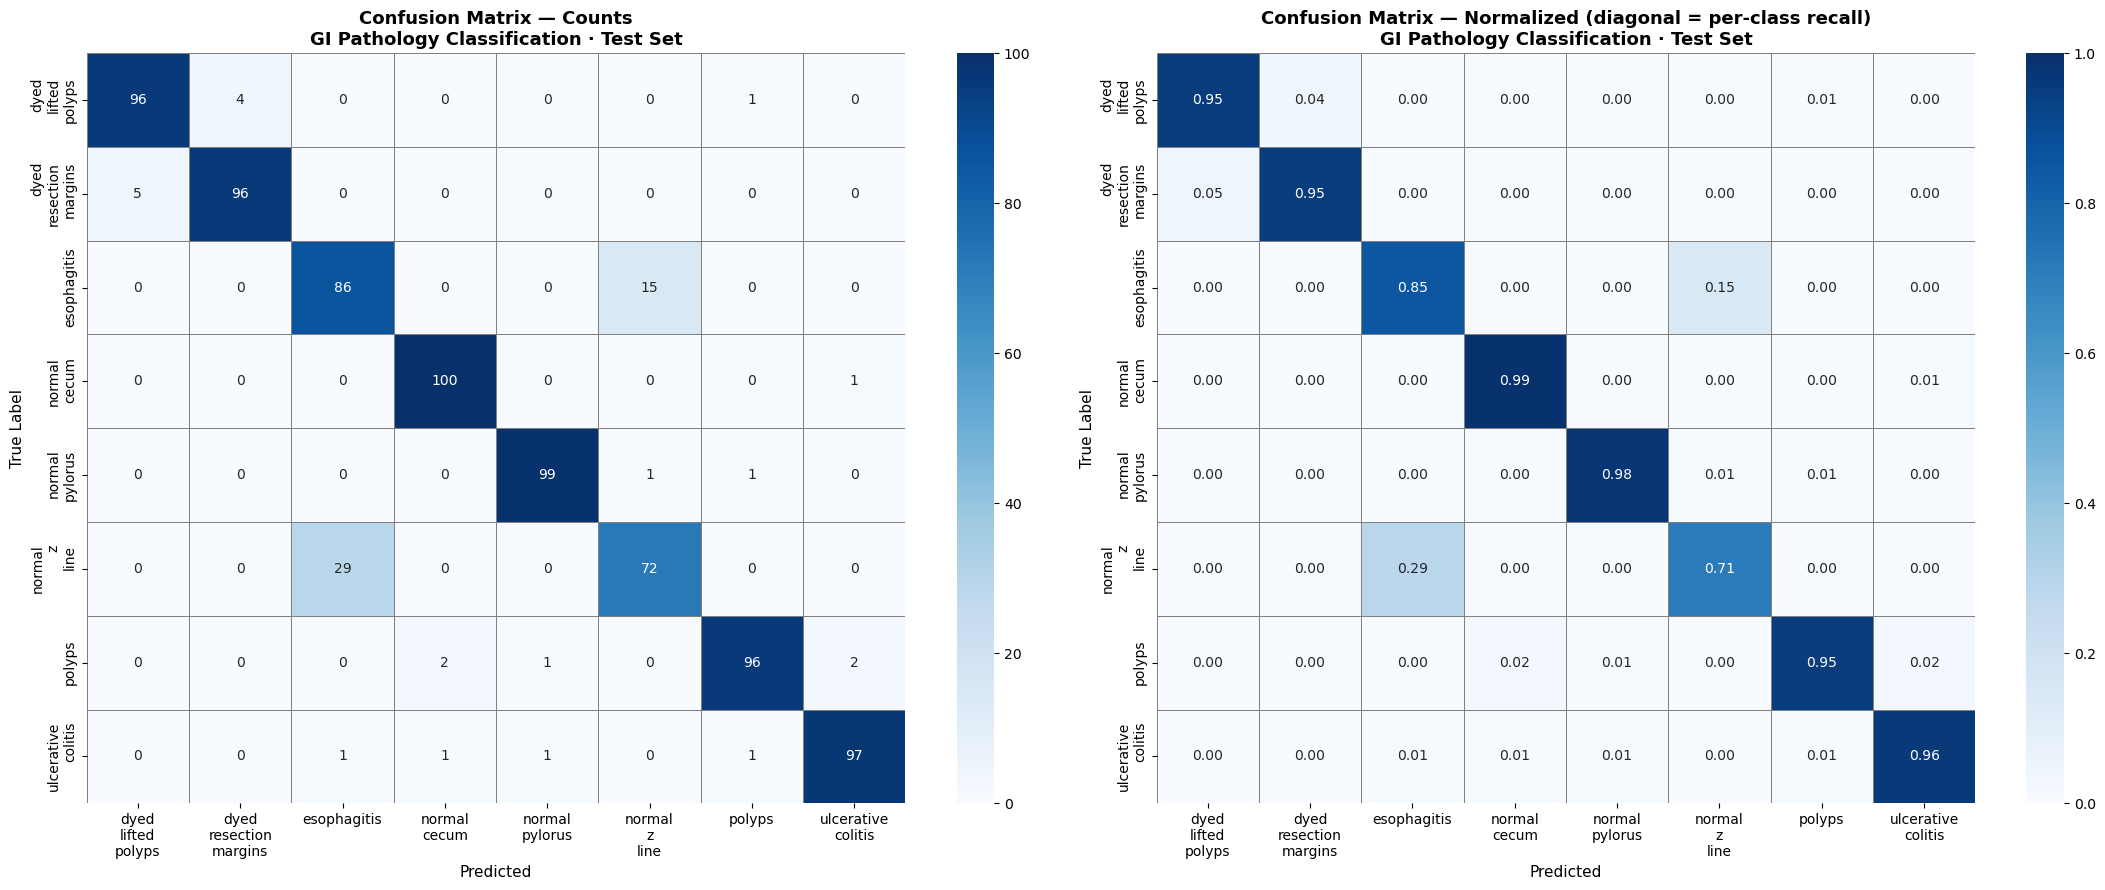

Saved → gi_class_confusion_matrix.png

Per-class Classification Report:
                        precision    recall  f1-score   support

    dyed-lifted-polyps      0.950     0.950     0.950       101
dyed-resection-margins      0.960     0.950     0.955       101
           esophagitis      0.741     0.851     0.793       101
          normal-cecum      0.971     0.990     0.980       101
        normal-pylorus      0.980     0.980     0.980       101
         normal-z-line      0.818     0.713     0.762       101
                polyps      0.970     0.950     0.960       101
    ulcerative-colitis      0.970     0.960     0.965       101

              accuracy                          0.918       808
             macro avg      0.920     0.918     0.918       808
          weighted avg      0.920     0.918     0.918       808



In [42]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

DISPLAY_NAMES = [n.replace("-", "\n") for n in class_names]

cm      = confusion_matrix(y_true_classes, y_pred_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES,
            linewidths=0.4, linecolor="gray")
axes[0].set_title("Confusion Matrix — Counts\nGI Pathology Classification · Test Set",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES,
            linewidths=0.4, linecolor="gray", vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix — Normalized (diagonal = per-class recall)\nGI Pathology Classification · Test Set",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig("gi_class_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → gi_class_confusion_matrix.png\n")

print("Per-class Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names, digits=3))

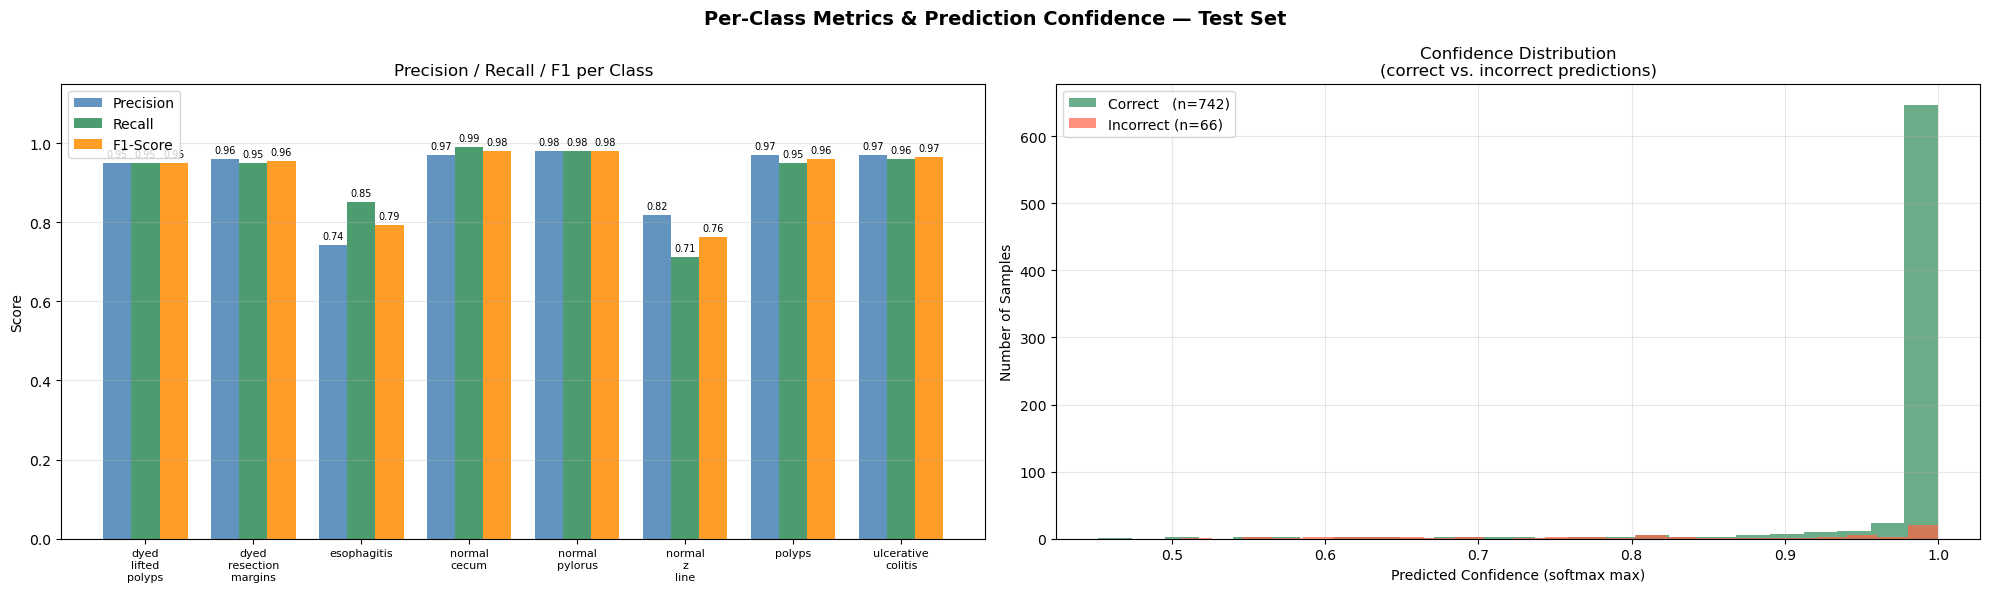

Saved → gi_class_metrics_per_class.png


In [44]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1_scores  = f1_score(y_true_classes,  y_pred_classes, average=None)
precision  = precision_score(y_true_classes, y_pred_classes, average=None)
recall_arr = recall_score(y_true_classes,    y_pred_classes, average=None)

x     = np.arange(len(class_names))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Per-Class Metrics & Prediction Confidence — Test Set", fontsize=14, fontweight="bold")

# Grouped bar chart: precision / recall / F1 per class
bars_p = axes[0].bar(x - width, precision,  width, label="Precision", color="steelblue",  alpha=0.85)
bars_r = axes[0].bar(x,          recall_arr, width, label="Recall",    color="seagreen",   alpha=0.85)
bars_f = axes[0].bar(x + width,  f1_scores,  width, label="F1-Score",  color="darkorange", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace("-", "\n") for n in class_names], fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 per Class")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar in [*bars_p, *bars_r, *bars_f]:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

# Confidence histogram: correct vs incorrect
correct_mask = y_pred_classes == y_true_classes
axes[1].hist(top_confidence[correct_mask],  bins=25, alpha=0.7, color="seagreen",
             label=f"Correct   (n={correct_mask.sum()})")
axes[1].hist(top_confidence[~correct_mask], bins=25, alpha=0.7, color="tomato",
             label=f"Incorrect (n={(~correct_mask).sum()})")
axes[1].set_xlabel("Predicted Confidence (softmax max)")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Confidence Distribution\n(correct vs. incorrect predictions)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gi_class_metrics_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → gi_class_metrics_per_class.png")

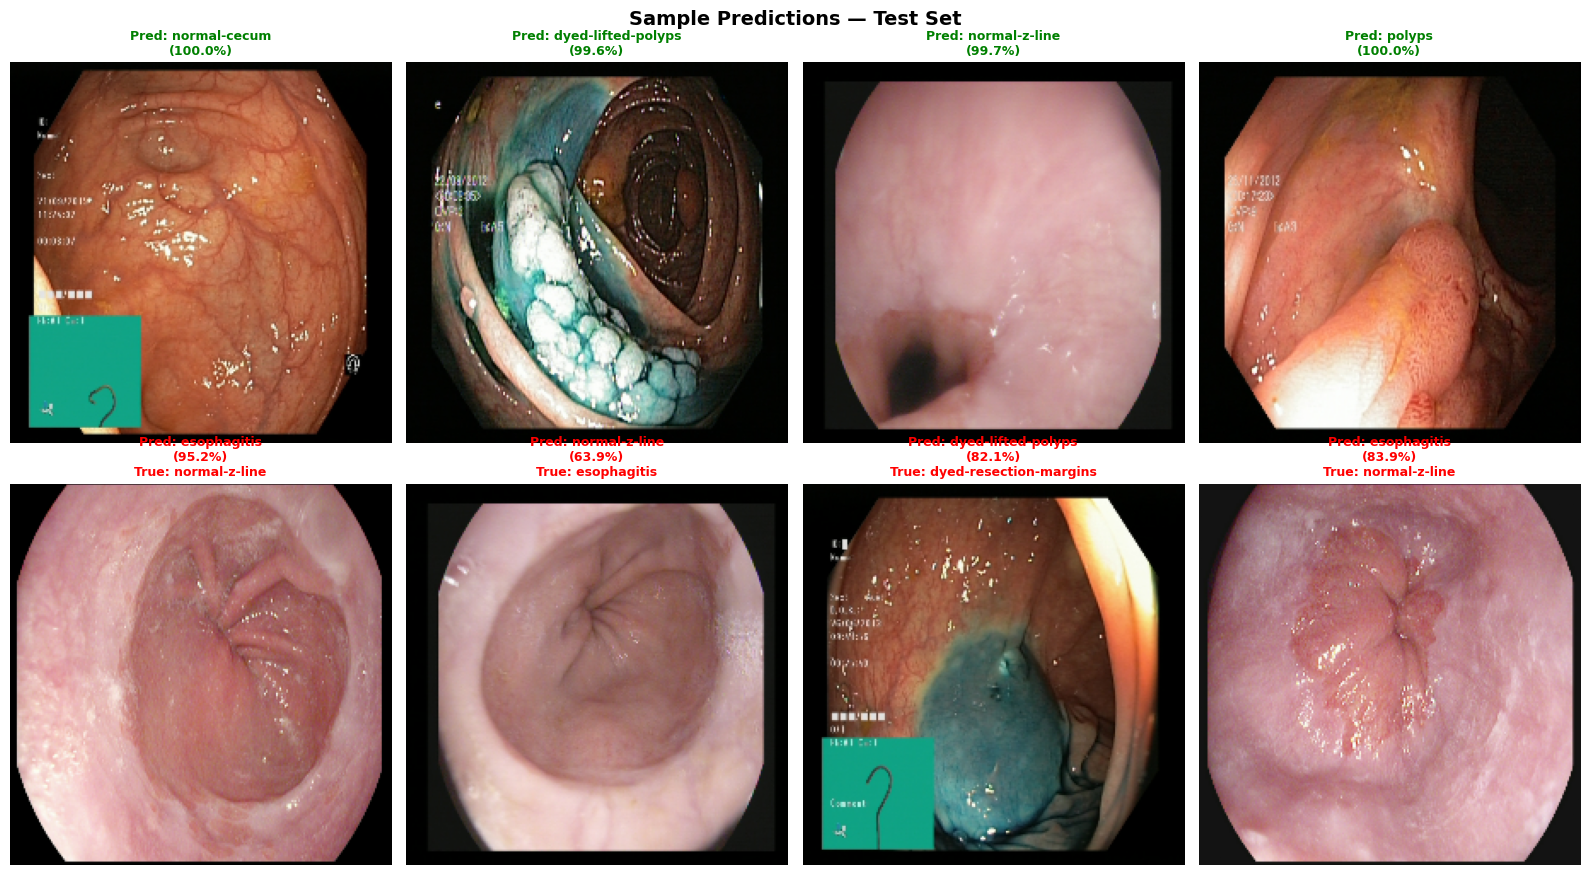

Saved → gi_class_sample_predictions.png


In [46]:
def plot_prediction_gallery(images, y_true, y_pred, probs, class_names, n=4, seed=42):
    """Grid of n correct + n incorrect predictions with confidence scores."""
    rng = np.random.default_rng(seed)

    correct_idx = np.where(y_pred == y_true)[0]
    wrong_idx   = np.where(y_pred != y_true)[0]

    correct_sample = rng.choice(correct_idx, min(n, len(correct_idx)), replace=False)
    wrong_sample   = rng.choice(wrong_idx,   min(n, len(wrong_idx)),   replace=False)

    fig, axes = plt.subplots(2, n, figsize=(n * 4, 9))
    fig.suptitle("Sample Predictions — Test Set", fontsize=14, fontweight="bold")

    for row, (indices, header) in enumerate(
        zip([correct_sample, wrong_sample], ["Correct Predictions", "Incorrect Predictions"])
    ):
        axes[row, 0].set_ylabel(header, fontsize=11, fontweight="bold", labelpad=12)
        for col, idx in enumerate(indices):
            axes[row, col].imshow(images[idx])
            pred_name = class_names[y_pred[idx]]
            true_name = class_names[y_true[idx]]
            conf      = probs[idx, y_pred[idx]]
            color     = "green" if y_pred[idx] == y_true[idx] else "red"
            title     = f"Pred: {pred_name}\n({conf:.1%})"
            if y_pred[idx] != y_true[idx]:
                title += f"\nTrue: {true_name}"
            axes[row, col].set_title(title, color=color, fontsize=9, fontweight="bold")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.savefig("gi_class_sample_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → gi_class_sample_predictions.png")


plot_prediction_gallery(X_test_np, y_true_classes, y_pred_classes, y_pred_probs, class_names, n=4)